<a href="https://colab.research.google.com/github/parthnayyar07/mausammix/blob/main/notebooks/mausammix_blending.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MausamMix: Adaptive Blending of AI and Physics Weather Forecasts for India
**Smart India Hackathon 2026 · SIH26081 · Ministry of Earth Sciences**

This notebook blends forecasts from a physics model (**ECMWF IFS HRES**) and an AI model (**Pangu-Weather**) over India, using ERA5 as ground truth. All data streams from the public [WeatherBench 2](https://weatherbench2.readthedocs.io/en/latest/data-guide.html) bucket — no login needed.

**How to run:** Runtime → Run all. If the first cell installs packages it restarts the runtime automatically — then click Run all once more.

## 1. Setup

In [1]:
# Installs zarr + gcsfs if missing, then restarts the runtime so xarray can see them.
import importlib.util, subprocess, sys, os
if importlib.util.find_spec("zarr") is None or importlib.util.find_spec("gcsfs") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "zarr", "gcsfs"])
    print("Installed. Runtime will restart now - then do Runtime > Run all again.")
    os.kill(os.getpid(), 9)
print("zarr and gcsfs ready")

zarr and gcsfs ready


In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({"font.size": 12, "legend.fontsize": 11})

# Save everything to Google Drive so a disconnect never loses work
from google.colab import drive
drive.mount("/content/drive")
SAVE = "/content/drive/MyDrive/sih081"
FIG = f"{SAVE}/figures"
os.makedirs(FIG, exist_ok=True)

OPTS = {"token": "anon"}                      # public bucket
BASE = "gs://weatherbench2/datasets"
VAR = "2m_temperature"
INDIA = dict(latitude=slice(5, 40), longitude=slice(65, 100))
LEAD_DAYS = [1, 3, 5, 7, 10]
START, END = "2018-01-01", "2022-12-20"       # end early so all valid times exist
TUNE = slice("2018-01-01", "2019-12-31")      # used only for design choices
TEST = slice("2020-01-01", "2022-12-20")      # all reported results
print("Saving to:", SAVE)

Mounted at /content/drive
Saving to: /content/drive/MyDrive/sih081


## 2. Load data from WeatherBench 2
1.5° grid, India domain (5–40°N, 65–100°E). Opening is lazy — nothing downloads until needed.

In [3]:
def load_india(path, var=VAR):
    ds = xr.open_zarr(path, storage_options=OPTS, decode_timedelta=True)
    return ds[var].sortby("latitude").sortby("longitude").sel(**INDIA)

hres  = load_india(f"{BASE}/hres/2016-2022-0012-240x121_equiangular_with_poles_conservative.zarr")
pangu = load_india(f"{BASE}/pangu/2018-2022_0012_240x121_equiangular_with_poles_conservative.zarr")
era5  = load_india(f"{BASE}/era5/1959-2023_01_10-6h-240x121_equiangular_with_poles_conservative.zarr")

for name, da in [("IFS HRES", hres), ("Pangu-Weather", pangu), ("ERA5 truth", era5)]:
    print(f"{name:14s}", dict(da.sizes))

IFS HRES       {'time': 5114, 'prediction_timedelta': 41, 'longitude': 23, 'latitude': 23}
Pangu-Weather  {'time': 3652, 'prediction_timedelta': 40, 'longitude': 23, 'latitude': 23}
ERA5 truth     {'time': 93544, 'longitude': 23, 'latitude': 23}


## 3. Align each forecast with what actually happened
For a forecast issued at time *t* with lead *L*, the truth is ERA5 at *t + L*. Only 00 UTC runs are used. The result is cached to Drive, so this slow step runs only once.

In [4]:
CACHE = f"{SAVE}/india_t2m.nc"

def align(fc, truth, lead_days):
    lead = np.timedelta64(lead_days, "D")
    f = fc.sel(prediction_timedelta=lead).sel(time=slice(START, END))
    f = f.sel(time=f.time[f.time.dt.hour == 0])
    t = truth.sel(time=f.time.values + lead).assign_coords(time=f.time.values)
    return f, t

if not os.path.exists(CACHE):
    parts = {}
    for d in LEAD_DAYS:
        print(f"downloading day {d} ...", end=" ")
        fh, th = align(hres, era5, d)
        fp, _ = align(pangu, era5, d)
        fh, fp, th = xr.align(fh, fp, th, join="inner")
        parts[f"hres_d{d}"] = fh.load().drop_vars("prediction_timedelta", errors="ignore")
        parts[f"pangu_d{d}"] = fp.load().drop_vars("prediction_timedelta", errors="ignore")
        parts[f"truth_d{d}"] = th.load()
        print(fh.sizes["time"], "dates")
    xr.Dataset(parts).to_netcdf(CACHE)

out = xr.open_dataset(CACHE).load()
store = {d: {k: out[f"{k}_d{d}"] for k in ("hres", "pangu", "truth")} for d in LEAD_DAYS}
print("forecast dates per lead:", store[1]["hres"].sizes["time"])

forecast dates per lead: 1815


## 4. Baseline: how good is each model on its own?

In [5]:
def rmse(f, t):
    w = np.cos(np.deg2rad(f.latitude))        # latitude weighting
    return float(np.sqrt(((f - t) ** 2).weighted(w).mean()))

rows = []
for d in LEAD_DAYS:
    s = store[d]
    tr = s["truth"].sel(time=TEST)
    rows.append({"lead_day": d,
                 "HRES": rmse(s["hres"].sel(time=TEST), tr),
                 "Pangu": rmse(s["pangu"].sel(time=TEST), tr)})
df_base = pd.DataFrame(rows)
print("RMSE (K), test years 2020-2022, verified against ERA5")
print(df_base.round(3).to_string(index=False))

RMSE (K), test years 2020-2022, verified against ERA5
 lead_day  HRES  Pangu
        1 1.573  0.794
        3 1.660  1.065
        5 1.729  1.278
        7 1.860  1.537
       10 2.135  1.941


## 5. Verification fairness check
Pangu-Weather starts from ERA5, while IFS HRES starts from ECMWF's own analysis. Verifying HRES against its own analysis (HRES t=0) shows how much the choice of "truth" matters.

In [6]:
FAIR = f"{SAVE}/results_fair.csv"
if not os.path.exists(FAIR):
    hres_t0 = load_india(f"{BASE}/hres_t0/2016-2022-6h-240x121_equiangular_with_poles_conservative.zarr")
    rows = []
    for d in LEAD_DAYS:
        s = store[d]
        lead = np.timedelta64(d, "D")
        ta = hres_t0.sel(time=s["hres"].time.values + lead).assign_coords(time=s["hres"].time.values).load()
        rows.append({"lead_day": d,
                     "HRES_vs_ERA5": rmse(s["hres"].sel(time=TEST), s["truth"].sel(time=TEST)),
                     "HRES_vs_analysis": rmse(s["hres"].sel(time=TEST), ta.sel(time=TEST)),
                     "Pangu_vs_ERA5": rmse(s["pangu"].sel(time=TEST), s["truth"].sel(time=TEST))})
    pd.DataFrame(rows).to_csv(FAIR, index=False)

df_fair = pd.read_csv(FAIR)
print(df_fair.round(3).to_string(index=False))

 lead_day  HRES_vs_ERA5  HRES_vs_analysis  Pangu_vs_ERA5
        1         1.573             0.508          0.794
        3         1.660             0.734          1.065
        5         1.729             0.915          1.278
        7         1.860             1.157          1.537
       10         2.135             1.569          1.941


## 6. MausamMix: bias-corrected adaptive blending
For each grid cell and lead time:
1. **Bias correction** — subtract each model's mean error over the previous 30 days.
2. **Skill weighting** — weight each corrected model by the inverse of its recent mean squared error.
3. **Blend** — combine with the learned weights.

**No future information:** for a forecast issued on day *t* at lead *L*, statistics use only forecasts issued on or before *t − L − 1*, whose outcomes were already known.

In [7]:
def past(x, shift, window=30):
    return x.shift(time=shift).rolling(time=window, min_periods=10).mean()

def skill_weighted_blend(f1, f2, truth, lead_days):
    shift = lead_days + 1
    m1 = past((f1 - truth) ** 2, shift)
    m2 = past((f2 - truth) ** 2, shift)
    w1 = (1 / (m1 + 1e-6)) / ((1 / (m1 + 1e-6)) + (1 / (m2 + 1e-6)))
    return w1 * f1 + (1 - w1) * f2, w1

def bias_corrected_blend(f1, f2, truth, lead_days):
    shift = lead_days + 1
    c1 = f1 - past(f1 - truth, shift)
    c2 = f2 - past(f2 - truth, shift)
    m1 = past((c1 - truth) ** 2, shift)
    m2 = past((c2 - truth) ** 2, shift)
    i1, i2 = 1 / (m1 + 1e-6), 1 / (m2 + 1e-6)
    w1 = i1 / (i1 + i2)
    return w1 * c1 + (1 - w1) * c2, w1

rows = []
for d in LEAD_DAYS:
    s = store[d]
    tr = s["truth"].sel(time=TEST)
    sw, _ = skill_weighted_blend(s["hres"], s["pangu"], s["truth"], d)
    bc, w = bias_corrected_blend(s["hres"], s["pangu"], s["truth"], d)
    s["final_blend"], s["final_w"] = bc, w
    eq = (s["hres"] + s["pangu"]) / 2
    rows.append({"lead_day": d,
                 "HRES": rmse(s["hres"].sel(time=TEST), tr),
                 "Pangu": rmse(s["pangu"].sel(time=TEST), tr),
                 "EqualBlend": rmse(eq.sel(time=TEST), tr),
                 "SkillWeighted": rmse(sw.sel(time=TEST), tr),
                 "MausamMix": rmse(bc.sel(time=TEST), tr)})

df_all = pd.DataFrame(rows)
df_all["gain_%"] = 100 * (1 - df_all["MausamMix"] / df_all[["HRES", "Pangu"]].min(axis=1))
print("RMSE (K), test years 2020-2022")
print(df_all.round(3).to_string(index=False))

df_f = df_all[["lead_day", "HRES", "Pangu", "EqualBlend", "MausamMix", "gain_%"]].copy()
df_f.round(3).to_csv(f"{SAVE}/table1_results_final.csv", index=False)
df_fair.round(3).to_csv(f"{SAVE}/table2_verification_fairness.csv", index=False)

RMSE (K), test years 2020-2022
 lead_day  HRES  Pangu  EqualBlend  SkillWeighted  MausamMix  gain_%
        1 1.573  0.794       1.010          0.793      0.730   8.157
        3 1.660  1.065       1.192          1.043      0.900  15.464
        5 1.729  1.278       1.324          1.218      1.048  17.984
        7 1.860  1.537       1.500          1.429      1.256  18.279
       10 2.135  1.941       1.802          1.768      1.615  16.823


## 7. Leakage check

In [8]:
d = 5
w = store[d]["final_w"]
first_valid = str(w.dropna("time", how="all").time[0].values)[:10]
print("lead (days):", d, "| shift used (days):", d + 1)
print("data starts:          ", str(w.time[0].values)[:10])
print("first defined weight: ", first_valid)
print("-> weights exist only after a full window of past, already-verified forecasts")

lead (days): 5 | shift used (days): 6
data starts:           2018-01-01
first defined weight:  2018-01-31
-> weights exist only after a full window of past, already-verified forecasts


## 8. What the system learns: weights by region and season

In [9]:
w5 = store[5]["final_w"].sel(time=TEST)
SEASONS = {"Winter (DJF)": [12, 1, 2], "Pre-monsoon (MAM)": [3, 4, 5],
           "Monsoon (JJAS)": [6, 7, 8, 9], "Post-monsoon (ON)": [10, 11]}

print("Mean weight on HRES (Day 5):")
for name, m in SEASONS.items():
    print(f"  {name:18s} {float(w5.sel(time=w5.time.dt.month.isin(m)).mean()):.3f}")

mon = w5.sel(time=w5.time.dt.month.isin([6, 7, 8, 9])).mean("time")
win = w5.sel(time=w5.time.dt.month.isin([12, 1, 2])).mean("time")
shift_map = mon - win
print("Largest seasonal shift in one location:", round(float(abs(shift_map).max()), 3))

Mean weight on HRES (Day 5):
  Winter (DJF)       0.449
  Pre-monsoon (MAM)  0.456
  Monsoon (JJAS)     0.419
  Post-monsoon (ON)  0.424
Largest seasonal shift in one location: 0.216


## 9. Figures for the presentation

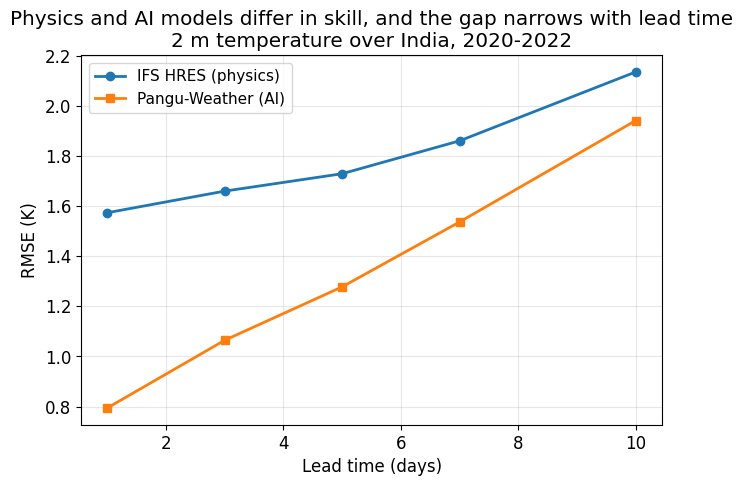

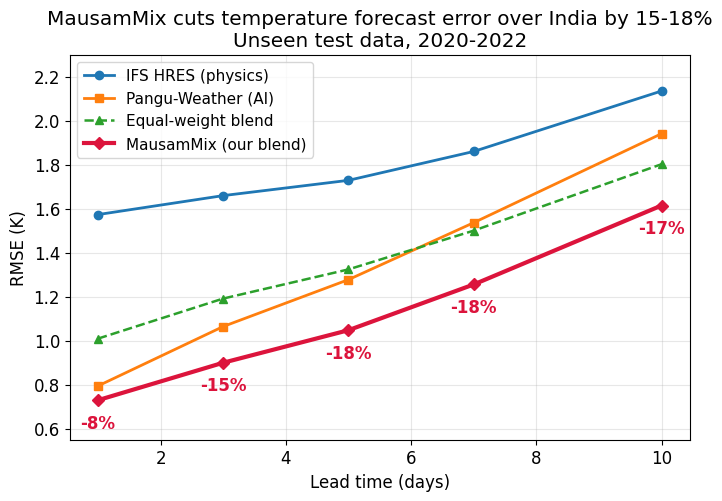

In [10]:
x = df_f["lead_day"]

# Fig 1: models on their own
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(x, df_f["HRES"], "o-", lw=2, label="IFS HRES (physics)")
ax.plot(x, df_f["Pangu"], "s-", lw=2, label="Pangu-Weather (AI)")
ax.set(xlabel="Lead time (days)", ylabel="RMSE (K)")
ax.set_title("Physics and AI models differ in skill, and the gap narrows with lead time\n2 m temperature over India, 2020-2022")
ax.legend(); ax.grid(alpha=0.3)
fig.savefig(f"{FIG}/fig1_model_comparison.png", dpi=300, bbox_inches="tight"); plt.show()

# Fig 2: headline result
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, df_f["HRES"], "o-", lw=2, label="IFS HRES (physics)")
ax.plot(x, df_f["Pangu"], "s-", lw=2, label="Pangu-Weather (AI)")
ax.plot(x, df_f["EqualBlend"], "^--", lw=1.8, label="Equal-weight blend")
ax.plot(x, df_f["MausamMix"], "D-", color="crimson", lw=3, label="MausamMix (our blend)")
for i in range(len(df_f)):
    ax.annotate(f"-{df_f['gain_%'][i]:.0f}%", (x[i], df_f["MausamMix"][i]), xytext=(0, -20),
                textcoords="offset points", ha="center", color="crimson", fontweight="bold")
ax.set(xlabel="Lead time (days)", ylabel="RMSE (K)", ylim=(0.55, 2.3))
lo, hi = df_f["gain_%"][1:].min(), df_f["gain_%"][1:].max()
ax.set_title(f"MausamMix cuts temperature forecast error over India by {lo:.0f}-{hi:.0f}%\nUnseen test data, 2020-2022")
ax.legend(loc="upper left"); ax.grid(alpha=0.3)
fig.savefig(f"{FIG}/fig2_headline_result.png", dpi=300, bbox_inches="tight"); plt.show()

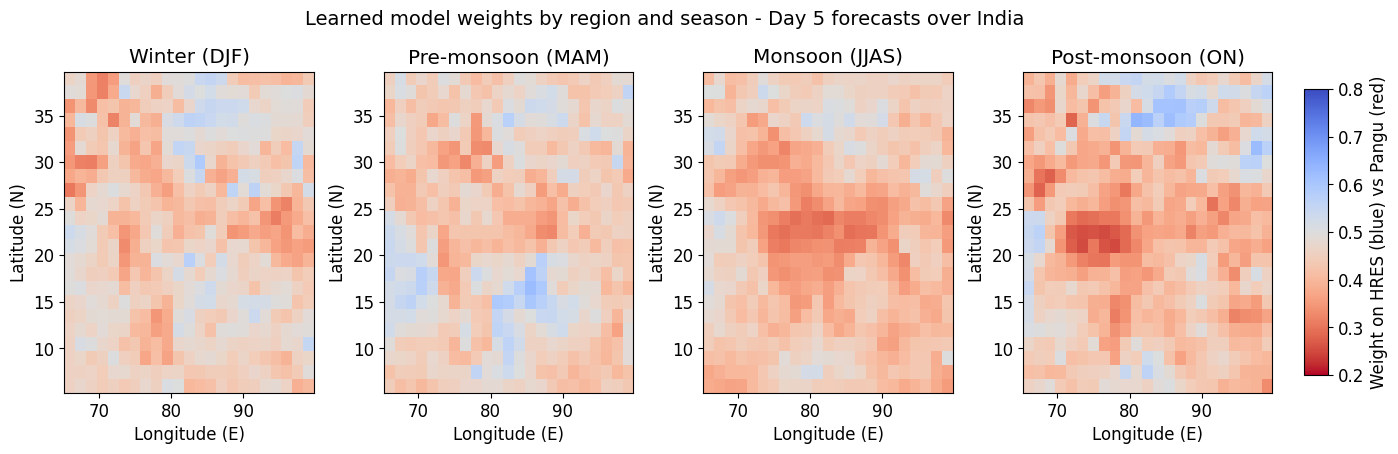

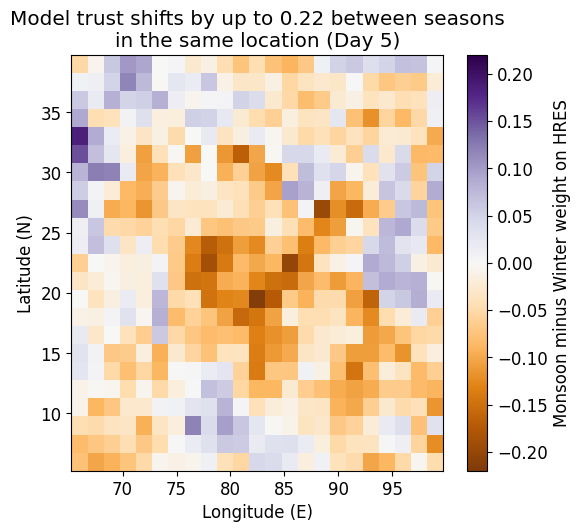

In [11]:
# Fig 3: weight maps by season
fig, axes = plt.subplots(1, 4, figsize=(16, 4.4))
for ax, (name, m) in zip(axes, SEASONS.items()):
    ws = w5.sel(time=w5.time.dt.month.isin(m)).mean("time")
    im = ws.plot(ax=ax, x="longitude", y="latitude", vmin=0.2, vmax=0.8, cmap="coolwarm_r", add_colorbar=False)
    ax.set(title=name, xlabel="Longitude (E)", ylabel="Latitude (N)")
fig.subplots_adjust(right=0.88, top=0.84, wspace=0.28)
fig.colorbar(im, cax=fig.add_axes([0.9, 0.15, 0.015, 0.65]), label="Weight on HRES (blue) vs Pangu (red)")
fig.suptitle("Learned model weights by region and season - Day 5 forecasts over India", fontsize=14)
fig.savefig(f"{FIG}/fig3_weight_maps.png", dpi=300, bbox_inches="tight"); plt.show()

# Fig 4: seasonal shift
fig, ax = plt.subplots(figsize=(6, 5.4))
shift_map.plot(ax=ax, x="longitude", y="latitude", cmap="PuOr", vmin=-0.22, vmax=0.22,
               cbar_kwargs={"label": "Monsoon minus Winter weight on HRES"})
ax.set(xlabel="Longitude (E)", ylabel="Latitude (N)")
ax.set_title(f"Model trust shifts by up to {float(abs(shift_map).max()):.2f} between seasons\nin the same location (Day 5)")
fig.savefig(f"{FIG}/fig4_seasonal_shift.png", dpi=300, bbox_inches="tight"); plt.show()

Typical monsoon day: 2021-07-12 | gain that day: 15.7 %


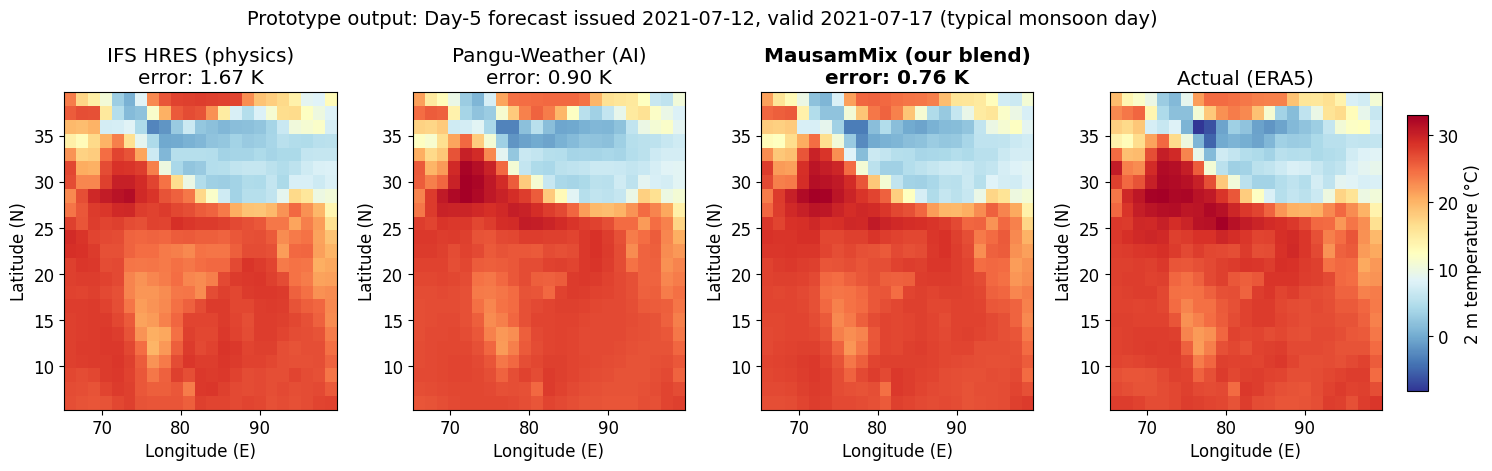

In [12]:
# Fig 5: prototype output for a TYPICAL monsoon day (median improvement, not the best day)
d = 5
s = store[d]
tr, h, p, b = (s[k].sel(time=TEST) for k in ("truth", "hres", "pangu", "final_blend"))
wlat = np.cos(np.deg2rad(tr.latitude))
day_rmse = lambda f: np.sqrt(((f - tr) ** 2).weighted(wlat).mean(["latitude", "longitude"]))
r_h, r_p, r_b = day_rmse(h), day_rmse(p), day_rmse(b)
gain = 100 * (1 - r_b / np.minimum(r_h, r_p))
g_m = gain.where(gain.time.dt.month.isin([6, 7, 8, 9]), drop=True)
pick = g_m.time.values[int(np.argmin(np.abs(g_m.values - float(g_m.median()))))]
init_str, valid_str = str(pick)[:10], str(pick + np.timedelta64(d, "D"))[:10]
print("Typical monsoon day:", init_str, "| gain that day:", round(float(gain.sel(time=pick)), 1), "%")

panels = [("IFS HRES (physics)", h, r_h), ("Pangu-Weather (AI)", p, r_p),
          ("MausamMix (our blend)", b, r_b), ("Actual (ERA5)", tr, None)]
vmin = float(tr.sel(time=pick).min()) - 273.15
vmax = float(tr.sel(time=pick).max()) - 273.15
fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
for ax, (name, da, r) in zip(axes, panels):
    im = (da.sel(time=pick) - 273.15).plot(ax=ax, x="longitude", y="latitude", cmap="RdYlBu_r",
                                           vmin=vmin, vmax=vmax, add_colorbar=False)
    title = name if r is None else f"{name}\nerror: {float(r.sel(time=pick)):.2f} K"
    ax.set_title(title, fontweight="bold" if "MausamMix" in name else "normal")
    ax.set(xlabel="Longitude (E)", ylabel="Latitude (N)")
fig.subplots_adjust(right=0.9, top=0.8, wspace=0.28)
fig.colorbar(im, cax=fig.add_axes([0.915, 0.15, 0.012, 0.6]), label="2 m temperature (°C)")
fig.suptitle(f"Prototype output: Day-5 forecast issued {init_str}, valid {valid_str} (typical monsoon day)", fontsize=14)
fig.savefig(f"{FIG}/fig5_prototype_output.png", dpi=300, bbox_inches="tight"); plt.show()

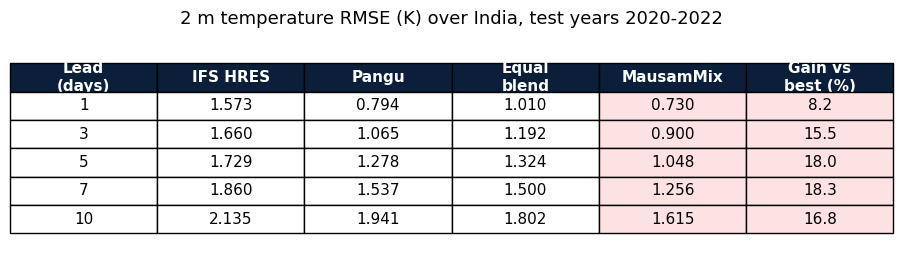

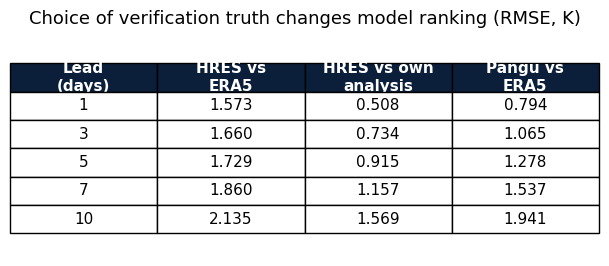

In [13]:
# Tables as images for the slides
def table_png(df, cols, title, fname, highlight=()):
    t = df.copy()
    t.columns = cols
    t[cols[0]] = t[cols[0]].astype(int)
    for c in cols[1:]:
        t[c] = t[c].map(lambda v: f"{v:.1f}" if "%" in c else f"{v:.3f}")
    fig, ax = plt.subplots(figsize=(1.9 * len(cols), 2.8))
    ax.axis("off")
    tb = ax.table(cellText=t.values, colLabels=cols, loc="center", cellLoc="center")
    tb.auto_set_font_size(False); tb.set_fontsize(11); tb.scale(1, 1.7)
    for j in range(len(cols)):
        tb[0, j].set_facecolor("#0B1F3A")
        tb[0, j].get_text().set_color("white")
        tb[0, j].get_text().set_fontweight("bold")
    for j in highlight:
        for i in range(1, len(t) + 1):
            tb[i, j].set_facecolor("#FDE2E4")
    ax.set_title(title, fontsize=13, pad=12)
    fig.savefig(f"{FIG}/{fname}", dpi=300, bbox_inches="tight"); plt.show()

table_png(df_f, ["Lead\n(days)", "IFS HRES", "Pangu", "Equal\nblend", "MausamMix", "Gain vs\nbest (%)"],
          "2 m temperature RMSE (K) over India, test years 2020-2022", "table1_results_final.png", highlight=(4, 5))
table_png(df_fair, ["Lead\n(days)", "HRES vs\nERA5", "HRES vs own\nanalysis", "Pangu vs\nERA5"],
          "Choice of verification truth changes model ranking (RMSE, K)", "table2_verification_fairness.png")

## 10. Download all outputs (optional)

In [14]:
import shutil
from google.colab import files
shutil.copy(f"{SAVE}/table1_results_final.csv", FIG)
shutil.copy(f"{SAVE}/table2_verification_fairness.csv", FIG)
shutil.make_archive("/content/mausammix_outputs", "zip", FIG)
files.download("/content/mausammix_outputs.zip")
print(sorted(os.listdir(FIG)))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

['fig1_model_comparison.png', 'fig2_headline_result.png', 'fig3_weight_maps.png', 'fig4_seasonal_shift.png', 'fig5_prototype_output.png', 'table1_results_final.csv', 'table1_results_final.png', 'table2_verification_fairness.csv', 'table2_verification_fairness.png']
